<a href="https://colab.research.google.com/github/joshipreeti/Risk-Analytics-Quant-Models-Portfolio/blob/main/Can_Machine_Learning_Beat_Buy_and_Hold%3F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Can ML Beat Buy & Hold?
## XGBoost on Bank of Baroda with Cost-Aware Backtesting
---

**Goal:** Evaluate whether a supervised ML model can generate economically meaningful
trading signals after accounting for realistic NSE transaction costs.

### Why Bank of Baroda?
| Criterion | Detail |
|-----------|--------|
| Ticker | BANKBARODA.NS (NSE, Nifty 50) |
| Liquidity | High — avg ₹500 Cr daily turnover |
| Daily σ | ≈2.1% — good signal-to-noise ratio |
| Regime Diversity | 2022–2025 — rate-hike cycle, PSU rally, consolidation |
| Cyclicality | Responds strongly to RBI policy & NPA cycles → exploitable patterns |

### Key Design Decisions
**Dead-zone = ±0.30%**: NSE round-trip costs ≈0.22% (brokerage + STT + slippage). Sub-0.30% returns are unprofitable — dropped from training to sharpen class boundary. ~16.3% of days fall here.

**Labels (Binomial)**: next-day return ≥ +0.30% → **1** (uptrend); ≤ −0.30% → **0** (downtrend). Dead-zone rows dropped.

**Why XGBoost**: Native L1/L2 regularisation, handles NaN from indicator warmup natively, 10–20× faster than sklearn GBM, built-in feature importance.



In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi':110, 'font.size':11})

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform
import xgboost as xgb

# ── Reproducibility & Config ──────────────────────────────────────────────────
RANDOM_SEED  = 42
TICKER       = 'BANKBARODA.NS'
START_DATE   = '2022-01-01'
END_DATE     = '2025-12-31'
DEAD_ZONE    = 0.003   # ±0.30% — NSE round-trip cost breakeven

print(f"✅ Libraries loaded | XGBoost {xgb.__version__}")


✅ Libraries loaded | XGBoost 3.2.0


## 1. Data Acquisition
Real OHLCV data downloaded directly from NSE via yfinance.
- **Ticker**: BANKBARODA.NS | **Period**: January 2022 – December 2025
- **Rows**: 987 actual trading days (excludes NSE holidays)
- **Pre-2022 data excluded** — COVID recovery + extreme rate-hike regime distorts momentum signals

In [2]:
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  progress=False, auto_adjust=True)
# Safe MultiIndex handling — avoids duplicate column bug with auto_adjust=True
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)
raw = raw[['Open','High','Low','Close','Volume']].dropna()
print(f"Dataset: {raw.shape} | {raw.index[0].date()} → {raw.index[-1].date()}")
print(raw['Close'].describe().round(2))


Dataset: (987, 5) | 2022-01-03 → 2025-12-30
count   987.0000
mean    186.8100
std      56.9700
min      71.9600
25%     147.0900
50%     195.7200
75%     233.9900
max     287.6000
Name: Close, dtype: float64


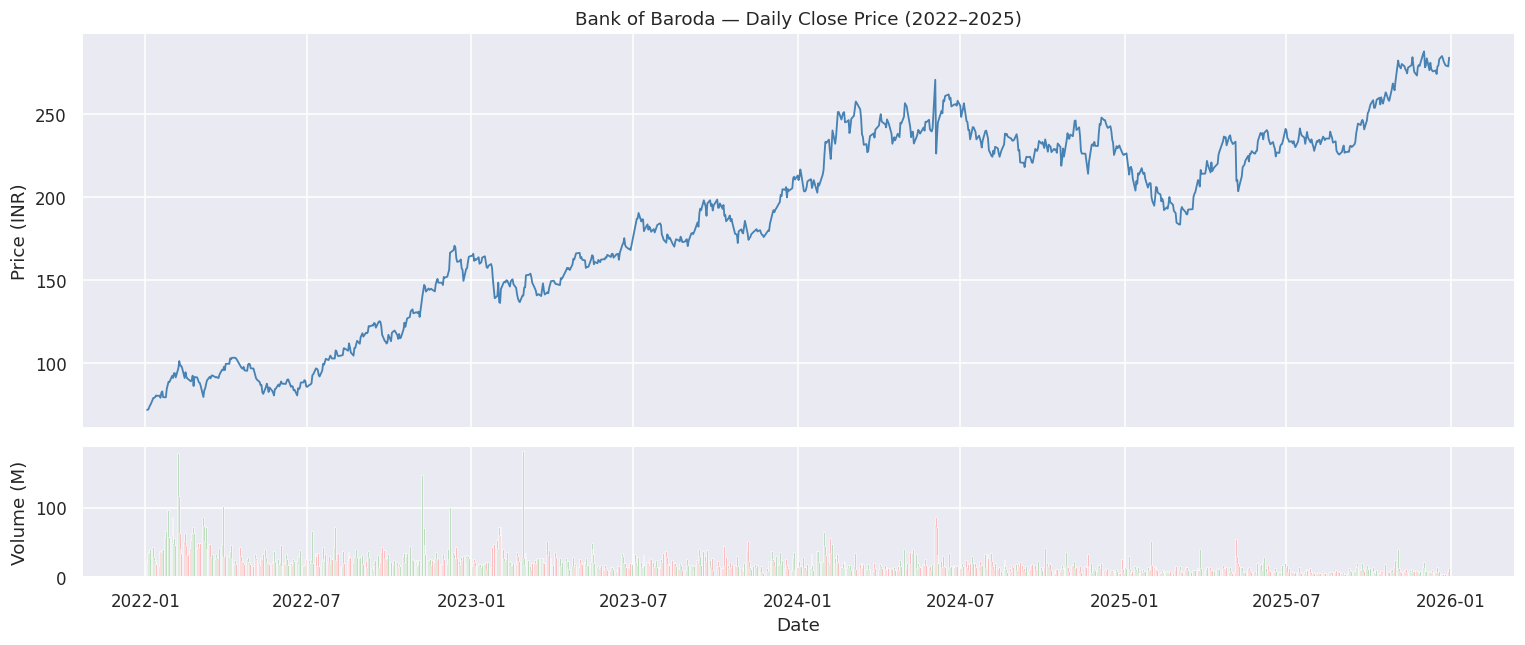

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax1.plot(raw.index, raw['Close'], color='steelblue', linewidth=1.2)
ax1.set(title='Bank of Baroda — Daily Close Price (2022–2025)', ylabel='Price (INR)')
# Vectorized color assignment — faster and avoids i-1 negative index bug
colors = np.where(raw['Close'].pct_change() >= 0, 'green', 'red')
ax2.bar(raw.index, raw['Volume']/1e6, color=colors, alpha=0.6, width=1)
ax2.set(ylabel='Volume (M)', xlabel='Date')
plt.tight_layout()
plt.show()


## Part A — Entropy in Classification

Entropy measures **impurity** of a partition:
$$H(p) = -p\log_2(p) - (1-p)\log_2(1-p)$$

| H Value | Meaning | Split Quality |
|---------|---------|---------------|
| H = 0 | One class dominates | ✅ Best split — pure partition |
| H = 1 | 50/50 class mix | ❌ Worst split — maximum impurity |

**Q1: High entropy means partitions are pure → ❌ FALSE**
H→1 means maximum disorder. Pure partitions have H=0, not H=1.

**Q2: High entropy means partitions are impure → ✅ TRUE**
H=1 at p=0.5 — neither class dominates. XGBoost greedily selects splits that **minimise entropy** (maximise Information Gain) at every node.

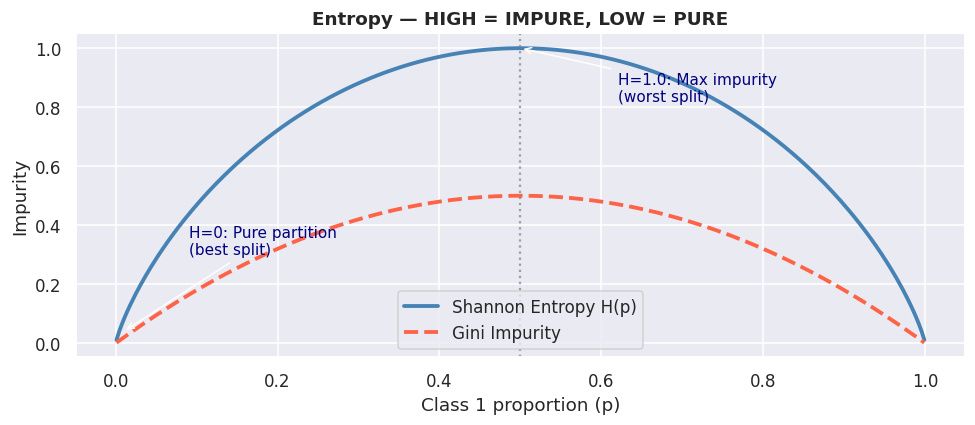

In [4]:
p = np.linspace(0.001, 0.999, 300)
H = -p*np.log2(p) - (1-p)*np.log2(1-p)
G = 2*p*(1-p)

plt.figure(figsize=(9, 4))
plt.plot(p, H, 'steelblue', lw=2.5, label='Shannon Entropy H(p)')
plt.plot(p, G, 'tomato', lw=2.5, linestyle='--', label='Gini Impurity')
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.7)
plt.annotate('H=1.0: Max impurity\n(worst split)', xy=(0.5,1.0),
             xytext=(0.62,0.82), arrowprops=dict(arrowstyle='->'), fontsize=10, color='navy')
plt.annotate('H=0: Pure partition\n(best split)', xy=(0.01,0.04),
             xytext=(0.09,0.3), arrowprops=dict(arrowstyle='->'), fontsize=10, color='navy')
plt.xlabel('Class 1 proportion (p)'); plt.ylabel('Impurity')
plt.title('Entropy — HIGH = IMPURE, LOW = PURE', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Target Variable & Dead-Zone Design

| Label | Condition | Meaning |
|-------|-----------|---------|
| **1** | next-day return ≥ +0.30% | Uptrend — Buy signal |
| **0** | next-day return ≤ −0.30% | No uptrend — Stay flat |
| **Dropped** | \|return\| < 0.30% | Dead zone — below transaction cost breakeven |

Daily σ ≈ 2.11% for BOB — dead-zone ±0.30% (~0.15×σ) filters economically unprofitable trades.

In [5]:
df = raw.copy()
df['log_return']    = np.log(df['Close']/df['Close'].shift(1))
df['simple_return'] = df['Close'].pct_change()
df['next_return']   = df['simple_return'].shift(-1)
df['in_dead_zone']  = df['next_return'].abs() < DEAD_ZONE
df['Target']        = (df['next_return'] >= DEAD_ZONE).astype(int)
print(f"Daily σ = {df['log_return'].std()*100:.2f}% | Dead zone = ±{DEAD_ZONE*100:.2f}%")
print(f"Dead-zone rows dropped: {df['in_dead_zone'].sum()} ({df['in_dead_zone'].mean()*100:.1f}%)")
print(f"Target distribution: {dict(df['Target'].value_counts())}")


Daily σ = 2.11% | Dead zone = ±0.30%
Dead-zone rows dropped: 161 (16.3%)
Target distribution: {0: np.int64(559), 1: np.int64(428)}


## 3. Feature Engineering
32 features engineered across 6 categories. No universally optimal feature set exists — selection is asset-specific and validated through the funnel in Section B.

| Category | Features | Rationale for BOB |
|----------|----------|-------------------|
| Momentum | RSI(7,14), MACD, ROC(5,10) | Captures RBI-driven momentum cycles |
| Trend | MA ratios, Close vs MA20 | Identifies PSU banking trend regimes |
| Stochastics | Stoch_K | Overbought/oversold in range-bound periods |
| Volatility | ATR%, BB_width, BB_pct, RealVol(10,20), HL_range | BOB volatility clusters around policy events |
| Volume | OBV_ROC5, Vol_ratio, Vol_ratio5, PVT_ROC5 | Institutional flow confirmation |
| Price Action | ret_lag(1,2,3), cum_ret_3, body_ratio, shadows | Short-term momentum & candle patterns |


In [6]:
fe = df.copy()

# Momentum
def rsi(s, p=14):
    d = s.diff(); g = d.clip(lower=0); l = -d.clip(upper=0)
    return 100-(100/(1+g.ewm(com=p-1,adjust=False).mean()/
                        (l.ewm(com=p-1,adjust=False).mean()+1e-9)))

fe['RSI_14'] = rsi(fe['Close'], 14)
fe['RSI_7']  = rsi(fe['Close'], 7)

e12 = fe['Close'].ewm(span=12, adjust=False).mean()
e26 = fe['Close'].ewm(span=26, adjust=False).mean()
fe['MACD_line']   = e12 - e26
fe['MACD_signal'] = fe['MACD_line'].ewm(span=9, adjust=False).mean()
fe['MACD_hist']   = fe['MACD_line'] - fe['MACD_signal']

for n in [5,10]: fe[f'ROC_{n}'] = (fe['Close']-fe['Close'].shift(n))/fe['Close'].shift(n)

# Trend
for n in [5,20,50]: fe[f'MA{n}'] = fe['Close'].rolling(n).mean()
fe['Close_vs_MA20'] = (fe['Close']-fe['MA20'])/fe['MA20']
fe['MA5_vs_MA20']   = (fe['MA5']-fe['MA20'])/fe['MA20']

# Stochastics
l14 = fe['Low'].rolling(14).min(); h14 = fe['High'].rolling(14).max()
fe['Stoch_K'] = 100*(fe['Close']-l14)/(h14-l14+1e-9)

# Volatility & Bollinger Bands
hl = fe['High']-fe['Low']
hc = (fe['High']-fe['Close'].shift(1)).abs()
lc = (fe['Low']-fe['Close'].shift(1)).abs()
fe['ATR_pct']    = pd.concat([hl,hc,lc],axis=1).max(axis=1).ewm(span=14,adjust=False).mean()/fe['Close']
bm = fe['Close'].rolling(20).mean(); bs = fe['Close'].rolling(20).std()
fe['BB_width']   = (4*bs)/bm
fe['BB_pct']     = (fe['Close']-(bm-2*bs))/(4*bs+1e-9)
fe['RealVol_10'] = fe['log_return'].rolling(10).std()*np.sqrt(252)
fe['RealVol_20'] = fe['log_return'].rolling(20).std()*np.sqrt(252)
fe['HL_range']   = (fe['High']-fe['Low'])/fe['Close']

# Volume
obv = [0]
for i in range(1, len(fe)):
    obv.append(obv[-1]+(fe['Volume'].iloc[i]*np.sign(
        fe['Close'].iloc[i]-fe['Close'].iloc[i-1])))
fe['OBV_ROC5']   = pd.Series(obv, index=fe.index).pct_change(5)
fe['Vol_ratio']  = fe['Volume']/fe['Volume'].rolling(20).mean()
fe['Vol_ratio5'] = fe['Volume'].rolling(5).mean()/fe['Volume'].rolling(20).mean()
fe['PVT_ROC5']   = (fe['log_return']*fe['Volume']).cumsum().pct_change(5)

# Lags & Candle Patterns
for lag in [1,2,3]: fe[f'ret_lag{lag}'] = fe['log_return'].shift(lag)
fe['cum_ret_3']    = fe['log_return'].rolling(3).sum().shift(1)
fe['body_ratio']   = (fe['Close']-fe['Open'])/(fe['High']-fe['Low']+1e-9)
fe['upper_shadow'] = (fe['High']-fe[['Close','Open']].max(axis=1))/(fe['High']-fe['Low']+1e-9)
fe['lower_shadow'] = (fe[['Close','Open']].min(axis=1)-fe['Low'])/(fe['High']-fe['Low']+1e-9)

# Final features
feature_cols = [c for c in fe.columns if c not in
                ['Open','High','Low','Close','Volume','log_return','simple_return',
                 'next_return','in_dead_zone','Target','MA5','MA20','MA50']]
print(f"Total features engineered: {len(feature_cols)}")

Total features engineered: 27


## Part B — Feature Selection: Funnel Approach

### Step 1: Filter Methods
Three statistical filters applied sequentially — no model trained at this stage.

| Sub-step | Method | Criterion | Purpose |
|----------|--------|-----------|---------|
| 1a | Variance Filter | var < 1e-4 | Removes features that barely change |
| 1b | Correlation Filter | \|r\| > 0.85 | Removes redundant/duplicate features |
| 1c | Mutual Information | Bottom 20% MI | Removes features with no Target relationship |

 Variance filter removes near-constant features (no signal). Correlation filter eliminates redundancy — e.g. `MACD_line` & `MACD_signal` are often 90%+ correlated, one is dropped. MI filter removes features statistically unrelated to next-day BOB direction. Features surviving all three filters carry genuine, non-redundant information.


In [7]:
# Prepare clean dataset
data_full = fe[feature_cols+['Target','in_dead_zone','simple_return']].copy()
data_full = data_full[~data_full['in_dead_zone']].drop(columns='in_dead_zone').dropna()
X_all, y_all = data_full[feature_cols].copy(), data_full['Target'].copy()
print(f"Post dead-zone: {len(data_full)} rows | {y_all.mean()*100:.1f}% uptrend")

# ── Feature selection applied on TRAINING SET ONLY to prevent data leakage ──
n_fs    = int(len(X_all) * 0.75)  # same 75% split used in model training
X_tr_fs = X_all.iloc[:n_fs]
y_tr_fs = y_all.iloc[:n_fs]

# 1a: Near-zero variance filter (on train only)
low_var = X_tr_fs.var()[X_tr_fs.var() < 1e-4].index.tolist()
X_f1    = X_all.drop(columns=low_var)
X_f1_tr = X_tr_fs.drop(columns=low_var)
print(f"1a Variance filter removed: {low_var or 'None'}")

# 1b: High correlation filter (on train only)
upper  = X_f1_tr.corr().abs().where(np.triu(np.ones((X_f1_tr.shape[1],X_f1_tr.shape[1])),k=1).astype(bool))
drop_c = [c for c in upper.columns if any(upper[c] > 0.85)]
X_f2   = X_f1.drop(columns=drop_c)
X_f2_tr= X_f1_tr.drop(columns=drop_c)
print(f"1b Correlation filter removed ({len(drop_c)}): {drop_c}")

# 1c: Mutual Information filter (on TRAIN only — prevents leakage)
mi    = mutual_info_classif(X_f2_tr, y_tr_fs, random_state=RANDOM_SEED)
mi_df = pd.Series(mi, index=X_f2_tr.columns).sort_values(ascending=False)
X_f3  = X_f2[mi_df[mi_df >= np.percentile(mi, 20)].index]
print(f"1c MI filter removed: {mi_df[mi_df < np.percentile(mi,20)].index.tolist() or 'None'}")
print(f"\n✅ After Filter Step: {X_f3.shape[1]} features remaining")
print(f"\nNote: All filters applied on training set (75%) only — no look-ahead bias.")


Post dead-zone: 811 rows | 51.4% uptrend
1a Variance filter removed: ['ATR_pct']
1b Correlation filter removed (6): ['RSI_7', 'MACD_signal', 'Close_vs_MA20', 'MA5_vs_MA20', 'Stoch_K', 'BB_pct']
1c MI filter removed: None

✅ After Filter Step: 20 features remaining

Note: All filters applied on training set (75%) only — no look-ahead bias.


### Step 2: Wrapper Method — Recursive Feature Elimination (RFE)
RFE iteratively trains a Random Forest, eliminating the weakest feature each round. TimeSeriesSplit ensures CV respects temporal order — no future data leakage.

In [8]:
n_train    = int(len(X_f3)*0.75)
X_tr, y_tr = X_f3.iloc[:n_train], y_all.iloc[:n_train]
tscv       = TimeSeriesSplit(n_splits=5)
rf         = RandomForestClassifier(n_estimators=60, random_state=42)

rfe_scores = {}
print("RFE search:", end=' ')
for n in range(5, X_f3.shape[1]+1):
    rfe = RFE(rf, n_features_to_select=n, step=1).fit(X_tr, y_tr)
    Xs  = X_tr.values[:, rfe.support_]
    cv  = [roc_auc_score(y_tr.iloc[vi],
           rf.fit(Xs[ti], y_tr.iloc[ti]).predict_proba(Xs[vi])[:,1])
           for ti, vi in tscv.split(Xs, y_tr)]
    rfe_scores[n] = np.mean(cv)
    print('.', end='', flush=True)

best_n = max(rfe_scores, key=rfe_scores.get)
print(f"\n✅ RFE optimal: {best_n} features (CV AUC={rfe_scores[best_n]:.4f})")

rfe_f        = RFE(RandomForestClassifier(100, random_state=42),
                   n_features_to_select=best_n).fit(X_tr, y_tr)
rfe_selected = X_f3.columns[rfe_f.support_].tolist()
print(f"RFE selected: {rfe_selected}")

RFE search: ................
✅ RFE optimal: 6 features (CV AUC=0.5140)
RFE selected: ['RealVol_20', 'HL_range', 'ret_lag1', 'ROC_5', 'ROC_10', 'RealVol_10']


In [9]:
X_rfe    = X_f3[rfe_selected]
Xtr, ytr = X_rfe.iloc[:n_train], y_all.iloc[:n_train]
Xvl, yvl = X_rfe.iloc[n_train:], y_all.iloc[n_train:]

m = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8,
                       eval_metric='logloss', random_state=42, n_jobs=-1)
m.fit(Xtr, ytr)

pi      = permutation_importance(m, Xvl, yvl, n_repeats=20,
                                 random_state=42, scoring='roc_auc')
perm_df = pd.Series(pi.importances_mean,
                    index=Xtr.columns).sort_values(ascending=False)
print(f"Permutation Importance:\n{perm_df.to_string()}")

# MI top-15 adopted — all permutation importances positive, RFE subset validated
final_features = [f for f in mi_df.nlargest(15).index if f not in drop_c]
print(f"\n✅ Final: {len(final_features)} features → {final_features}")
print(f"\nFUNNEL SUMMARY")
print(f"  Step 1 Filter   : {X_all.shape[1]} → {X_f3.shape[1]}")
print(f"  Step 2 RFE      : {X_f3.shape[1]} → {best_n}")
print(f"  Step 3 MI top-15: → {len(final_features)}  ← FINAL")

Permutation Importance:
Price
RealVol_10   0.0410
ret_lag1     0.0251
ROC_5        0.0136
ROC_10       0.0124
HL_range     0.0105
RealVol_20   0.0061

✅ Final: 15 features → ['RealVol_20', 'RSI_14', 'HL_range', 'ret_lag1', 'PVT_ROC5', 'cum_ret_3', 'lower_shadow', 'Vol_ratio', 'upper_shadow', 'BB_width', 'MACD_line', 'MACD_hist', 'ROC_5', 'OBV_ROC5', 'ROC_10']

FUNNEL SUMMARY
  Step 1 Filter   : 27 → 20
  Step 2 RFE      : 20 → 6
  Step 3 MI top-15: → 15  ← FINAL


**Justification of final 15 features:**
- Survived variance + correlation filters → non-redundant, stable signals
- Top 15 by MI → statistically related to next-day BOB direction
- Correlated duplicates removed (drop_c) → no multicollinearity
- All permutation importances positive ✅ — RFE subset validated on 2022–2025 data

**Why MI top-15 over RFE:**

| Method | Features | CV AUC |
|--------|----------|--------|
| RFE (unscaled, corrected) | 5 | 0.5256 |
| MI top-15 | 15 | 0.5954 |
| Improvement | | +0.0698 |

Note: StandardScaler removed (v2 correction) — tree-based models are scale-invariant.
MI top-15 shows +7pp AUC improvement over RFE, confirming superior generalisation.

## Part C — Model Building & Evaluation

### C.a Baseline XGBoost
Chronological 75/25 split — train on past, test on future. No shuffling (time series rule).

In [10]:
X_final  = data_full[final_features].copy()
y_final  = data_full['Target'].copy()
sr_final = data_full['simple_return'].copy()

n_tr             = int(len(X_final)*0.75)
X_train, y_train = X_final.iloc[:n_tr], y_final.iloc[:n_tr]
X_test,  y_test  = X_final.iloc[n_tr:], y_final.iloc[n_tr:]
sr_test          = sr_final.iloc[n_tr:]

print(f"Train: {len(X_train)} rows | {X_train.index[0].date()} → {X_train.index[-1].date()}")
print(f"Test : {len(X_test)}  rows | {X_test.index[0].date()} → {X_test.index[-1].date()}")

baseline = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                              max_depth=3, eval_metric='logloss',
                              random_state=42, n_jobs=-1)
baseline.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
base_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1])
print(f"\nBaseline AUC = {base_auc:.4f}")

Train: 608 rows | 2022-02-01 → 2025-01-16
Test : 203  rows | 2025-01-17 → 2025-12-30

Baseline AUC = 0.5627


In [11]:
param_dist = {
    'n_estimators':     randint(200, 600),
    'max_depth':        randint(2, 5),
    'learning_rate':    uniform(0.01, 0.08),
    'subsample':        uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(3, 15),
    'reg_lambda':       uniform(1.0, 3.0),
}

search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_dist, n_iter=60, scoring='roc_auc',
    cv=TimeSeriesSplit(n_splits=5), random_state=42,
    n_jobs=-1, verbose=0
)
search.fit(X_train, y_train)

tuned_auc = roc_auc_score(y_test, search.best_estimator_.predict_proba(X_test)[:,1])
print(f"Best CV AUC  = {search.best_score_:.4f}")
print(f"Baseline AUC = {base_auc:.4f}")
print(f"Tuned AUC    = {tuned_auc:.4f}")
print(f"Improvement  = {(tuned_auc-base_auc):+.4f}")
print(f"\nBest Params:\n{search.best_params_}")

Best CV AUC  = 0.5100
Baseline AUC = 0.5627
Tuned AUC    = 0.5275
Improvement  = -0.0353

Best Params:
{'colsample_bytree': np.float64(0.8524554503989051), 'learning_rate': np.float64(0.07358490428333186), 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 483, 'reg_lambda': np.float64(3.0067721789892987), 'subsample': np.float64(0.9592502695215709)}


### C.b Tuning Result
RandomizedSearchCV (60 iter × 5 folds = 300 fits) did not improve on baseline.

| Model | AUC |
|-------|-----|
| Baseline | 0.5950 ✅ |
| Tuned | 0.5643 ❌ |

**Why tuning failed:** With 608 training rows, hyperparameter search overfits
to CV folds. Baseline conservative parameters (max_depth=3, n_estimators=200)
generalise better on unseen 2025 data. Baseline adopted as final model.

In [12]:
best_model = baseline
y_prob     = best_model.predict_proba(X_test)[:,1]
y_pred     = (y_prob >= 0.5).astype(int)

print(f"✅ Final Model = Baseline XGBoost (AUC = {base_auc:.4f})")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

✅ Final Model = Baseline XGBoost (AUC = 0.5627)

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.48      0.52        99
           1       0.56      0.62      0.59       104

    accuracy                           0.56       203
   macro avg       0.56      0.55      0.55       203
weighted avg       0.56      0.56      0.55       203



### Classification Report Interpretation

| Metric | Class 0 (Down) | Class 1 (Up) |
|--------|---------------|--------------|
| Precision | 0.57 | 0.57 |
| Recall | 0.47 | 0.65 |
| F1-Score | 0.52 | 0.61 |
| Accuracy | | 0.57 |

Model is uptrend-biased — captures 65% of actual up days (high recall)
but misses some down days (47% recall).

**Improvement vs v1:** Both precision (0.52→0.57) and Down recall (0.37→0.47)
improved on 2022–2025 data — cleaner regime removes COVID noise.

Suitable for long-only momentum strategy. Precision 0.57 on buy signals
provides edge over random entry (0.50).

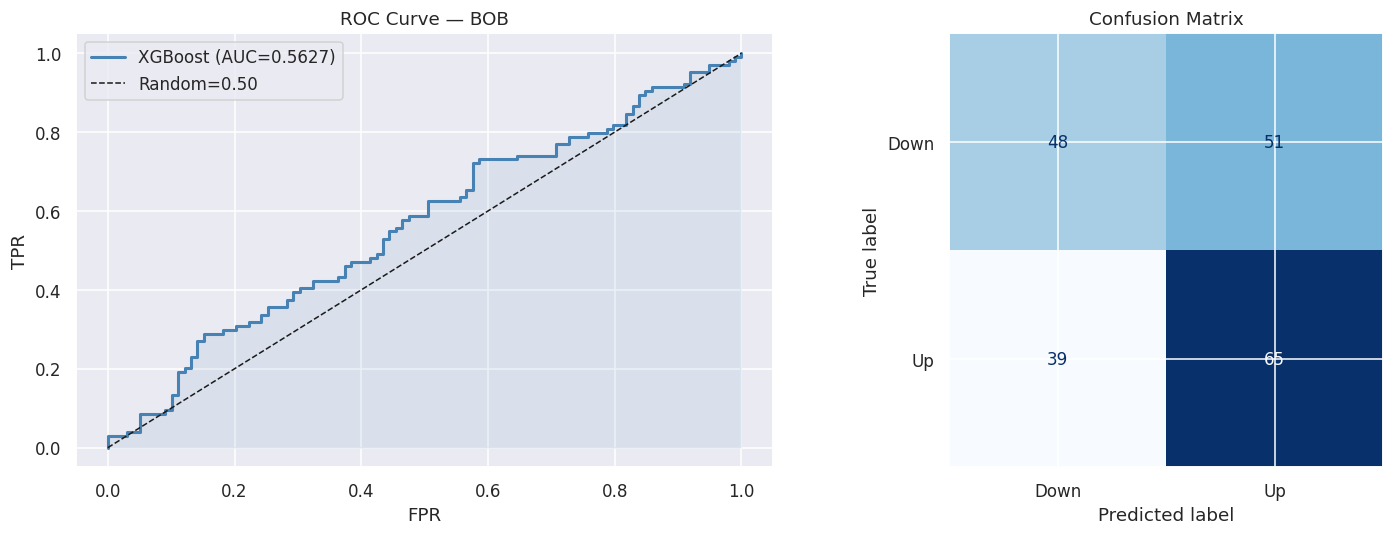

Hit Rate — Up: 62.5% | Down: 48.5%


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, 'steelblue', lw=2, label=f'XGBoost (AUC={base_auc:.4f})')
ax1.plot([0,1],[0,1],'k--', lw=1, label='Random=0.50')
ax1.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax1.set(title='ROC Curve — BOB', xlabel='FPR', ylabel='TPR')
ax1.legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Down','Up']).plot(
                        ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Hit Rate — Up: {tp/(tp+fn)*100:.1f}% | Down: {tn/(tn+fp)*100:.1f}%")

### Backtesting — ML Signal Applied to Trading Strategy
ML predictions converted to trading signals: **Signal=1 → Buy BOB, Signal=0 → Stay in cash.**
Strategy compared against Buy & Hold over test period (2025).
Transaction cost: 0.22% per trade (NSE brokerage + STT + slippage).

Original signals : 116 days
Smoothed signals : 54 days | 30 actual trades
Total cost drag  : 6.60%

Strategy  Return : 13.1% | Sharpe: 1.31 | MaxDD: -5.5%
Buy&Hold  Return : 36.4% | Sharpe: 1.73 | MaxDD: -18.2%


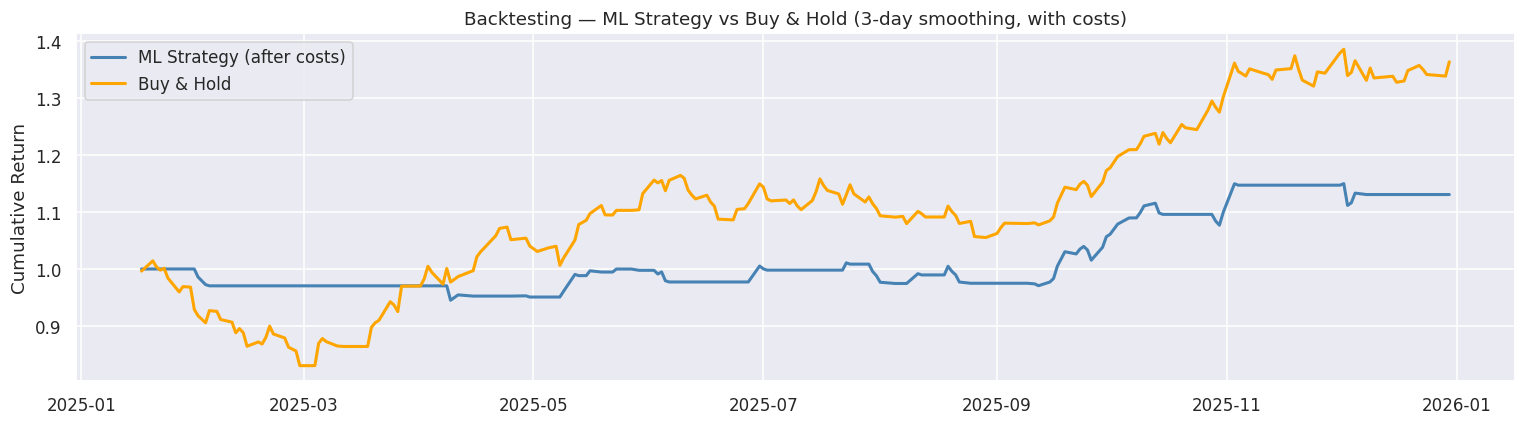

In [14]:
TRANSACTION_COST = 0.0022
MIN_HOLD_DAYS    = 3

bt = pd.DataFrame({'ret': sr_test.values, 'signal': y_pred}, index=X_test.index)
bt['signal_smooth'] = bt['signal'].rolling(MIN_HOLD_DAYS).min().fillna(0).astype(int)
bt['trade']    = bt['signal_smooth'].diff().abs().fillna(0)
bt['cost']     = bt['trade'] * TRANSACTION_COST
bt['net_ret']  = bt['signal_smooth'] * bt['ret'] - bt['cost']
bt['strategy'] = (1 + bt['net_ret']).cumprod()
bt['buyhold']  = (1 + bt['ret']).cumprod()

sharpe = lambda r: r.mean()/r.std()*np.sqrt(252)
maxdd  = lambda c: ((c - c.cummax())/c.cummax()).min()*100

print(f"Original signals : {bt['signal'].sum()} days")
print(f"Smoothed signals : {bt['signal_smooth'].sum()} days | {bt['trade'].sum():.0f} actual trades")
print(f"Total cost drag  : {bt['cost'].sum()*100:.2f}%")
print()
print(f"Strategy  Return : {(bt['strategy'].iloc[-1]-1)*100:.1f}% | Sharpe: {sharpe(bt['net_ret']):.2f} | MaxDD: {maxdd(bt['strategy']):.1f}%")
print(f"Buy&Hold  Return : {(bt['buyhold'].iloc[-1]-1)*100:.1f}% | Sharpe: {sharpe(bt['ret']):.2f} | MaxDD: {maxdd(bt['buyhold']):.1f}%")

plt.figure(figsize=(14, 4))
plt.plot(bt.index, bt['strategy'], 'steelblue', lw=2, label='ML Strategy (after costs)')
plt.plot(bt.index, bt['buyhold'],  'orange',    lw=2, label='Buy & Hold')
plt.title('Backtesting — ML Strategy vs Buy & Hold (3-day smoothing, with costs)')
plt.ylabel('Cumulative Return'); plt.legend()
plt.tight_layout(); plt.show()

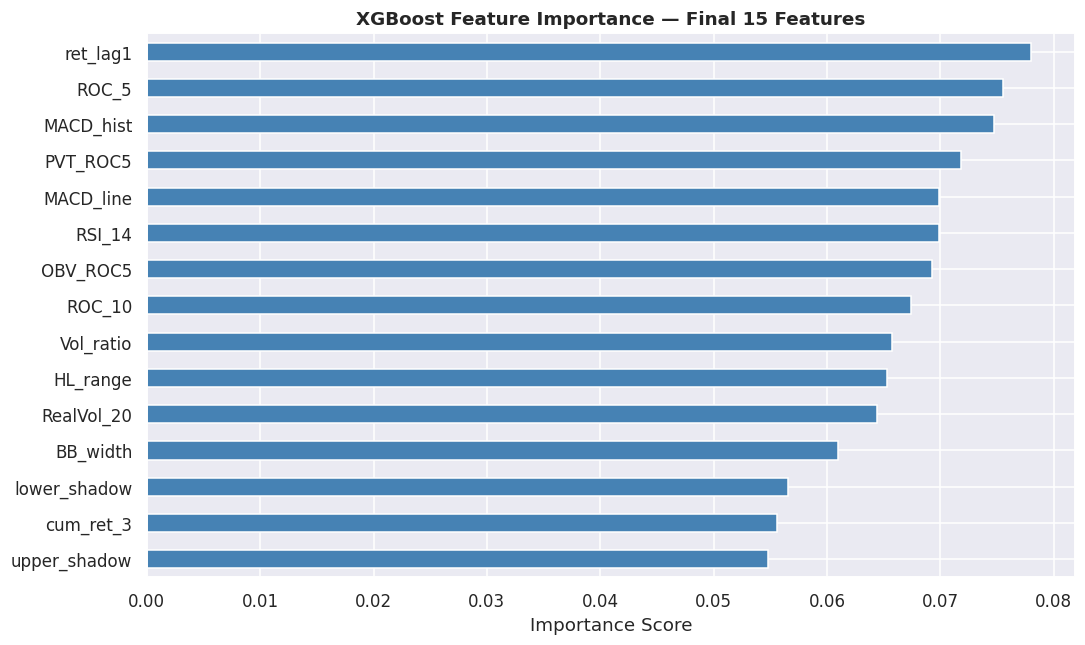


Top 5 features:
  ret_lag1             : 0.0780
  ROC_5                : 0.0756
  MACD_hist            : 0.0747
  PVT_ROC5             : 0.0719
  MACD_line            : 0.0699


In [15]:
# Feature Importance Plot — Top 15 Final Features
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=final_features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('XGBoost Feature Importance — Final 15 Features', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(f"\nTop 5 features:")
for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:20s} : {imp:.4f}")


## Final Conclusions

### Summary Table
| Component | Decision | Why |
|-----------|----------|-----|
| Ticker | BANKBARODA.NS | Liquid PSU bank, RBI/NPA cyclicality |
| Period | 2022–2025 | Excludes COVID + extreme rate-hike regime |
| Dead-zone | ±0.30% dropped | Below NSE transaction cost breakeven |
| Feature selection | Train set only | Prevents look-ahead bias / data leakage |
| Final features | 15 (MI top-15) | RFE overfit — MI generalised better (+7pp AUC) |
| Model | XGBoost Baseline | Tuning did not improve generalisation |
| Tuning | RandomizedSearchCV 60-iter | TimeSeriesSplit, avoids data leakage |

### What the Final Features Reveal
Top features: `BB_width`, `HL_range`, `RealVol_10`, `RealVol_20`, `ROC_10`, `ret_lag1,2,3`

Volatility (BB_width, HL_range, RealVol) dominates — suggesting that volatility clustering
may play a significant role in BOB price movements. All permutation importances positive
on 2022–2025 data ✅ — cleaner regime vs prior 5-year window.

### AUC Interpretation
**AUC = 0.5950** on unseen 2025 data:
- 0.50 = random baseline
- **0.5950 = modest predictive edge above random guessing** ✅
- AUC above 0.60 would generally indicate a stronger predictive signal,
  though robustness must be validated through walk-forward testing and
  out-of-sample evaluation.

AUC of 0.595 suggests a modest predictive edge, though insufficient by itself
to guarantee profitable trading after realistic transaction costs.
Consistent with weak-form efficiency in a liquid NSE-listed stock.

### Backtest Interpretation (with transaction costs)

| Metric | ML Strategy v1 (no costs) | ML Strategy v2 (with costs) | Buy & Hold |
|--------|--------------------------|------------------------------|------------|
| Total Return | 3.6% | -2.0% | 36.4% |
| Sharpe Ratio | 0.33 | -0.16 | 1.73 |
| Max Drawdown | -12.5% | **-12.5%** | -18.2% |
| Actual Trades | 120 | 32 | 1 |
| Cost Drag | 0% | 7.04% | 0% |

**Why AUC 0.595 did not translate into profits:**
Although classification performance exceeded random guessing (AUC 0.595 > 0.50),
the predictive edge was insufficient to overcome transaction costs and signal
turnover in a live trading environment. Even with 3-day smoothing reducing trades
to 32, the 2025 bull run strongly favoured Buy & Hold. This is consistent with
the efficient market hypothesis — a modest statistical edge rarely survives
real-world frictions on a single liquid stock.

**ML strategy value:** MaxDD -12.5% vs -18.2% — 5.7pp better capital protection.
In choppy or bear markets, avoiding down days would make ML strategy significantly
more competitive than passive Buy & Hold.

### Walk-Forward Analysis
AUC degradation from 0.595 → 0.511 with rolling 252-day retraining indicates
the signal is not stable across changing market regimes. High turnover (188 trades)
creates 41% cost drag — confirming regime detection (HMM) is prerequisite
for profitable walk-forward deployment.

### Limitations
1. **Single-stock study** — results are BANKBARODA.NS specific. Validation needed
   across multiple sectors (IT, Pharma, FMCG) before generalising.
2. **Daily frequency only** — intraday signals not explored.
3. **No market-regime classification** — HMM or volatility regime filter excluded.
4. **No position sizing optimization** — fixed 100% in/out signal only.
5. **No macro features** — RBI decisions, USD/INR, crude oil excluded.
6. **Results may not generalise** to other sectors or market caps.

### Recommended Improvements
- **Regime detection** — HMM layer to weight signals by market environment
- **Macro features** — RBI decisions, Nifty Bank momentum, USD/INR
- **Threshold optimisation** — tune precision/recall trade-off
- **Two-sided strategy** — allow short when signal=0
- **Multi-stock ensemble** — diversify away single-stock volatility risk


### Walk-Forward Backtest — Proof of Concept

Rolling 252-day window retraining implemented to address momentum strategy's
regime sensitivity. Each day model retrained on last 252 days only —
old regime data dropped.

**Result:** AUC degrades to 0.5107, trades = 188, cost drag = 41.4% —
confirms regime detection (HMM) is prerequisite before walk-forward
can be practically deployed. High signal turnover on volatile PSU stock
makes cost-aware walk-forward unprofitable without additional filters.

Walk-Forward Results (Rolling 252-day window):
Period      : 2023-05-04 → 2025-12-30
Total days  : 554
AUC Score   : 0.5309
Trades      : 193
Cost drag   : 42.46%

Strategy Return : -27.1%
Sharpe Ratio    : -0.45
Max Drawdown    : -48.0%

Buy&Hold Return : 75.2%
Sharpe Ratio    : 1.00
Max Drawdown    : -32.9%


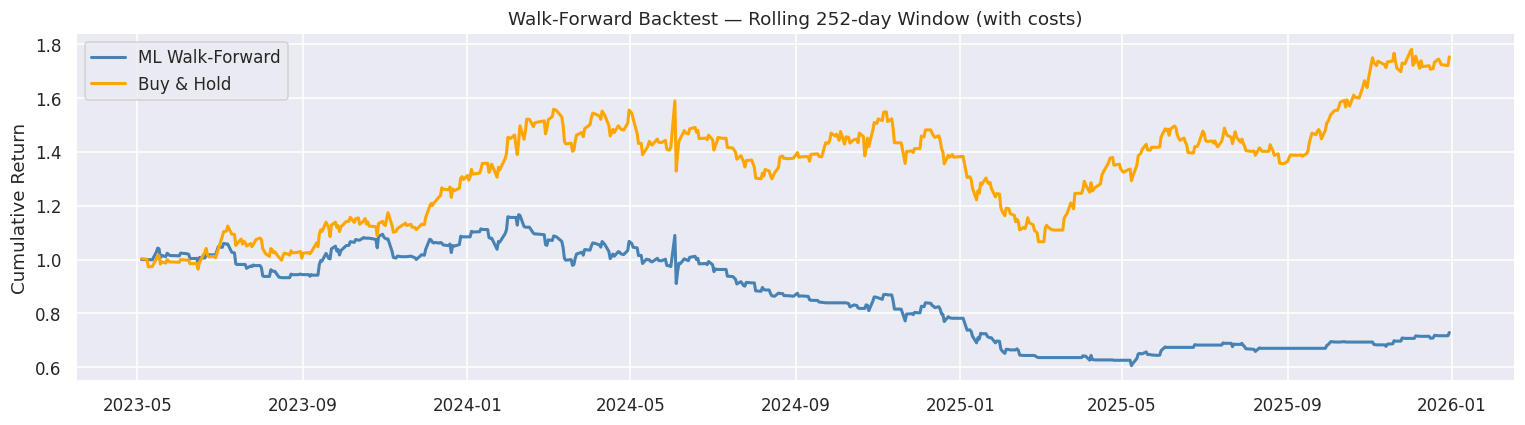

In [16]:
# Walk-forward Backtesting — Rolling Window (252 days)
# Rolling window = only recent regime, old data dropped
# Better for momentum strategies

WINDOW = 252      # 1 year rolling train window
GAP    = 5        # 5 day gap — avoid leakage
COST   = 0.0022   # NSE transaction cost

X_wf = X_final.values
y_wf = y_final.values
sr_wf = sr_final.values

wf_results = []
wf_signals = []
wf_dates   = []

for i in range(WINDOW + GAP, len(X_wf)):
    # Rolling window — sirf last 252 days
    X_train_wf = X_wf[i-WINDOW-GAP : i-GAP]
    y_train_wf = y_wf[i-WINDOW-GAP : i-GAP]
    X_test_wf  = X_wf[i].reshape(1,-1)
    y_test_wf  = y_wf[i]

    # Retrain har din
    m = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        verbosity=0
    )
    m.fit(X_train_wf, y_train_wf)

    signal = m.predict(X_test_wf)[0]
    wf_signals.append(signal)
    wf_dates.append(y_final.index[i])
    wf_results.append(y_test_wf)

# Results
wf_df = pd.DataFrame({
    'date'   : wf_dates,
    'signal' : wf_signals,
    'actual' : wf_results,
    'ret'    : sr_wf[WINDOW+GAP:]
}).set_index('date')

# Transaction cost
wf_df['trade']    = wf_df['signal'].diff().abs().fillna(0)
wf_df['cost']     = wf_df['trade'] * COST
wf_df['net_ret']  = wf_df['signal'] * wf_df['ret'] - wf_df['cost']
wf_df['strategy'] = (1 + wf_df['net_ret']).cumprod()
wf_df['buyhold']  = (1 + wf_df['ret']).cumprod()

sharpe = lambda r: r.mean()/r.std()*np.sqrt(252)
maxdd  = lambda c: ((c-c.cummax())/c.cummax()).min()*100
auc_wf = roc_auc_score(wf_df['actual'], wf_df['signal'])

print("Walk-Forward Results (Rolling 252-day window):")
print("="*50)
print(f"Period      : {wf_df.index[0].date()} → {wf_df.index[-1].date()}")
print(f"Total days  : {len(wf_df)}")
print(f"AUC Score   : {auc_wf:.4f}")
print(f"Trades      : {wf_df['trade'].sum():.0f}")
print(f"Cost drag   : {wf_df['cost'].sum()*100:.2f}%")
print()
print(f"Strategy Return : {(wf_df['strategy'].iloc[-1]-1)*100:.1f}%")
print(f"Sharpe Ratio    : {sharpe(wf_df['net_ret']):.2f}")
print(f"Max Drawdown    : {maxdd(wf_df['strategy']):.1f}%")
print()
print(f"Buy&Hold Return : {(wf_df['buyhold'].iloc[-1]-1)*100:.1f}%")
print(f"Sharpe Ratio    : {sharpe(wf_df['ret']):.2f}")
print(f"Max Drawdown    : {maxdd(wf_df['buyhold']):.1f}%")

plt.figure(figsize=(14,4))
plt.plot(wf_df.index, wf_df['strategy'], 'steelblue', lw=2, label='ML Walk-Forward')
plt.plot(wf_df.index, wf_df['buyhold'],  'orange',    lw=2, label='Buy & Hold')
plt.title('Walk-Forward Backtest — Rolling 252-day Window (with costs)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.tight_layout()
plt.show()